# Cartographies of Educational Risk
## Performance, gaps and digital inequality in secondary education

**Privacy-safe portfolio reconstruction**  
**Author:** Narella de los Santos

This repository reconstructs the methodology of a year-long educational analytics project while protecting the confidential source data.

The original academic notebook worked with a large attendance/grades table of **1,962,950 rows and 30 columns before cleaning**, plus contextual/student data and several weekly digital-platform activity sources. The public version deliberately uses a **smaller synthetic sample** so it can run quickly on any laptop.

### What is preserved from the original work

- source integration and student-level key strategy
- documented exclusion rules
- treatment of special/missing academic values
- the decision rule for suspicious isolated zero grades
- validation of the expected 11-subject curriculum
- transformation from subject × delivery rows to one row per student
- academic evolution, variability and range features
- cumulative-attendance → period-attendance transformation
- annual absence, average absence rate and volatility
- chronic absenteeism flag
- weekly digital activity aggregated to the same academic periods
- separate measures for actions, comments, login-days and task submissions
- period-specific digital-participation thresholds
- univariate and bivariate exploratory analysis
- categorical association tests and Spearman correlations
- urban/rural and over-age comparisons
- final risk label based on the August academic outcome
- Logistic Regression, Decision Tree, Random Forest and XGBoost
- train/test comparison and model-governance discussion

### Privacy principle

No original student rows, institution names, IDs, exact locations, file paths, Drive links or raw notebook outputs are published here. Synthetic data reproduce the analytical structure, not real individuals or schools.

## 1. Analytical architecture

The original project progressively integrated three analytical domains:

1. **Personal and contextual data** — student demographics and educational-center context.
2. **Attendance and grades** — repeated records at subject × evaluation-period level.
3. **Digital-platform activity** — weekly actions, comments, login-days and task submissions.

The common entity is the **student**. The final analytical grain is:

> **one row per student**

That grain is not assumed at ingestion time; it is created and validated after transforming the repeated operational records.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, spearmanr
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_auc_score
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 2. Synthetic source generation

The following source tables intentionally mimic the **structure** of the original problem.

The public sample is smaller than the confidential project. This is deliberate: the goal is to demonstrate methodology and engineering decisions, not reproduce sensitive records.

In [2]:
N = 8000
student_ids = np.arange(100000, 100000 + N)

context = pd.DataFrame({
    "student_id": student_ids,
    "sex": rng.choice(["F", "M"], N),
    "age": rng.choice([12,13,14,15,16,17], N, p=[0.18,0.36,0.25,0.11,0.07,0.03]),
    "zone": rng.choice(["Urban", "Rural"], N, p=[0.76,0.24]),
    "school_type": rng.choice(["Public", "Private", "Private-Free"], N, p=[0.88,0.08,0.04]),
    "vulnerability_index": np.clip(rng.normal(0.50, 0.20, N), 0, 1),
    "region": rng.choice(["North","South","East","West","Center"], N)
})

# Private-center vulnerability is intentionally unavailable, matching the methodological issue
# documented in the original project.
context.loc[context["school_type"] != "Public", "vulnerability_index"] = np.nan

context.head()

,student_id,sex,age,zone,school_type,vulnerability_index,region
0,100000,F,14,Urban,Public,0.710334,Center
1,100001,M,13,Urban,Private-Free,NaN,South
2,100002,M,15,Urban,Public,0.611001,South
3,100003,F,13,Rural,Public,0.534551,North
4,100004,F,13,Urban,Public,0.780752,North


In [3]:
periods = ["May", "June", "August", "Final"]
subjects = [f"Subject_{i:02d}" for i in range(1, 12)]

# Student latent performance, influenced by context only to make the synthetic example realistic.
base = pd.Series(
    rng.normal(6.8, 1.2, N)
    - (context["age"].to_numpy() >= 15) * 0.7
    - (context["vulnerability_index"].fillna(0.5).to_numpy() - 0.5) * 1.2,
    index=student_ids
)

rows=[]
for sid in student_ids:
    cumulative_abs = 0
    for p_idx, period in enumerate(periods):
        # cumulative official attendance counter
        cumulative_abs += max(0, int(rng.normal(4 + p_idx*2 + max(0, 6.5-base[sid])*1.4, 2.5)))
        for subject in subjects:
            grade = np.clip(base[sid] + rng.normal(0,0.9) - p_idx*0.10, 0, 10)
            rows.append([sid, subject, period, round(float(grade),1), cumulative_abs])

academic_long = pd.DataFrame(
    rows,
    columns=["student_id","subject","evaluation_period","grade","official_cumulative_absences"]
)

# Reproduce important source-quality issues from the original notebook:
# unrecorded values and isolated zero grades.
missing_mask = rng.random(len(academic_long)) < 0.012
academic_long.loc[missing_mask, "grade"] = np.nan

zero_mask = rng.random(len(academic_long)) < 0.004
academic_long.loc[zero_mask, "grade"] = 0.0

academic_long.shape, academic_long.head()

((352000, 5),
    student_id     subject  ... grade  official_cumulative_absences
 0      100000  Subject_01  ...   8.8                             0
 1      100000  Subject_02  ...   6.3                             0
 2      100000  Subject_03  ...   8.0                             0
 3      100000  Subject_04  ...   7.6                             0
 4      100000  Subject_05  ...   6.3                             0
 
 [5 rows x 5 columns])

In [4]:
# Weekly digital sources: weeks 9..52, four separate measures.
weeks = list(range(9,53))
digital = pd.DataFrame({"student_id": student_ids})

digital_propensity = np.clip(
    rng.gamma(2.2, 1.0, N)
    + (base.to_numpy()-6.0)*0.35
    - (context["age"].to_numpy()>=16)*0.35,
    0.1, None
)

for w in weeks:
    digital[f"actions_week_{w}"] = rng.poisson(4.5*digital_propensity)
    digital[f"comments_week_{w}"] = rng.poisson(0.22*digital_propensity)
    digital[f"logins_week_{w}"] = rng.poisson(1.15*digital_propensity)
    digital[f"submissions_week_{w}"] = rng.poisson(0.55*digital_propensity)

digital.head()

,student_id,actions_week_9,comments_week_9,logins_week_9,submissions_week_9,actions_week_10,comments_week_10,logins_week_10,submissions_week_10,actions_week_11,comments_week_11,logins_week_11,submissions_week_11,actions_week_12,comments_week_12,logins_week_12,submissions_week_12,actions_week_13,comments_week_13,logins_week_13,submissions_week_13,actions_week_14,comments_week_14,logins_week_14,submissions_week_14,actions_week_15,comments_week_15,logins_week_15,submissions_week_15,actions_week_16,comments_week_16,logins_week_16,submissions_week_16,actions_week_17,comments_week_17,logins_week_17,submissions_week_17,actions_week_18,comments_week_18,logins_week_18,...,actions_week_43,comments_week_43,logins_week_43,submissions_week_43,actions_week_44,comments_week_44,logins_week_44,submissions_week_44,actions_week_45,comments_week_45,logins_week_45,submissions_week_45,actions_week_46,comments_week_46,logins_week_46,submissions_week_46,actions_week_47,comments_week_47,logins_week_47,submissions_week_47,actions_week_48,comments_week_48,logins_week_48,submissions_week_48,actions_week_49,comments_week_49,logins_week_49,submissions_week_49,actions_week_50,comments_week_50,logins_week_50,submissions_week_50,actions_week_51,comments_week_51,logins_week_51,submissions_week_51,actions_week_52,comments_week_52,logins_week_52,submissions_week_52
0,100000,2,0,2,0,3,0,0,1,4,0,1,0,7,0,0,0,3,0,1,0,2,0,0,1,4,0,2,2,2,0,2,0,8,0,0,0,4,0,1,...,2,0,2,1,3,0,2,0,8,0,1,0,1,0,0,0,3,0,0,2,11,0,2,0,1,1,0,1,4,0,1,0,4,1,3,2,3,0,2,0
1,100001,9,0,2,1,12,1,3,1,5,0,5,1,3,0,1,0,11,1,2,0,7,0,2,0,7,2,4,0,7,1,1,0,12,0,0,0,5,0,4,...,11,0,2,0,7,0,1,0,8,0,4,0,14,0,1,1,13,0,2,0,11,1,3,1,8,0,4,2,15,1,2,2,10,0,3,2,8,0,3,0
2,100002,10,1,4,0,18,1,3,0,19,0,3,3,13,1,3,1,15,0,4,1,14,0,4,2,8,2,4,1,15,1,3,4,4,1,7,1,8,1,1,...,12,0,7,1,8,0,5,1,11,0,4,1,7,1,1,3,12,0,1,0,14,0,5,0,12,1,2,2,12,0,3,0,11,1,3,1,11,0,4,1
3,100003,2,0,1,0,3,0,0,2,4,1,0,0,8,0,1,0,3,0,0,2,7,0,2,1,2,1,1,0,1,0,1,0,3,0,0,0,6,0,4,...,7,0,1,0,4,0,2,0,3,0,1,0,4,0,3,1,3,0,0,1,4,0,1,0,6,0,4,0,4,1,1,0,2,1,1,0,4,0,3,0
4,100004,5,1,2,0,5,0,2,2,11,0,0,1,6,0,2,1,5,2,3,3,4,0,4,1,6,0,2,3,8,0,1,2,6,0,0,0,6,1,1,...,9,0,0,1,5,0,1,0,7,0,1,1,6,1,4,1,4,1,2,2,5,0,1,1,5,0,1,1,4,1,0,2,6,1,1,2,3,0,4,2


## 3. Cleaning strategy and exclusion rules

The original project documented exclusions as methodological decisions rather than treating them as arbitrary preprocessing.

### A. Exclude private educational centers
The socioeconomic vulnerability index was unavailable for private centers. Keeping those students while comparing vulnerability would create a systematic missingness problem.

### B. Exclude students aged 16+
The modeling objective was **early detection** in the expected 7th-grade cohort. Students aged 16+ represent established educational delay rather than emerging risk.

### C. Treat special/unavailable values as missing
Unrecorded academic values are not valid grades.

### D. Isolated zero-grade rule
A zero can be a valid academic result, but in the original data a zero with almost no supporting evaluations could also reflect a recording issue. Therefore an isolated `0.0` with ≤1 valid grade for that student/subject was treated as missing.

### E. Validate the 11-subject curriculum
Students outside the standard 11-subject structure were excluded from the standard-cohort analysis because they could correspond to alternative educational plans.

In [5]:
context_clean = (
    context
    .query("school_type == 'Public'")
    .query("age < 16")
    .copy()
)

valid_ids = set(context_clean["student_id"])
academic_clean = academic_long[academic_long["student_id"].isin(valid_ids)].copy()

# Isolated-zero validation by student/subject.
non_missing_counts = (
    academic_clean.groupby(["student_id","subject"])["grade"]
    .transform(lambda s: s.notna().sum())
)

isolated_zero = academic_clean["grade"].eq(0) & non_missing_counts.le(1)
academic_clean.loc[isolated_zero, "grade"] = np.nan

# Validate standard 11-subject cohort
subject_count = academic_clean.groupby("student_id")["subject"].nunique()
standard_ids = subject_count[subject_count.eq(11)].index

context_clean = context_clean[context_clean["student_id"].isin(standard_ids)].copy()
academic_clean = academic_clean[academic_clean["student_id"].isin(standard_ids)].copy()

print("Public early-risk cohort:", len(context_clean))
print("Academic long-table rows:", len(academic_clean))
print("Unique subjects per retained student:", academic_clean.groupby("student_id")["subject"].nunique().unique())

Public early-risk cohort: 6413
Academic long-table rows: 282172
Unique subjects per retained student: [11]


## 4. Academic aggregation and grade transformation

The operational table contains many rows per student because the same student appears once for each **subject × evaluation period**.

The transformation layer creates:

- average grade by evaluation period
- global average
- standard deviation of grades
- total grade range
- early academic trend

Independent validation calculations are included to verify that the derived metrics match a fresh aggregation from the source table.

In [6]:
period_avg = (
    academic_clean.groupby(["student_id","evaluation_period"])["grade"]
    .mean()
    .unstack()
    .rename(columns={
        "May":"avg_may",
        "June":"avg_june",
        "August":"avg_august",
        "Final":"avg_final"
    })
    .reset_index()
)

global_grade = (
    academic_clean.groupby("student_id")["grade"]
    .agg(
        avg_grade_total="mean",
        grade_std_total="std",
        grade_min="min",
        grade_max="max"
    )
    .reset_index()
)
global_grade["grade_range_total"] = global_grade["grade_max"] - global_grade["grade_min"]

grades = period_avg.merge(global_grade, on="student_id", how="left")
grades["trend_may_to_august"] = grades["avg_august"] - grades["avg_may"]

grades.head()

,student_id,avg_august,avg_final,avg_june,avg_may,avg_grade_total,grade_std_total,grade_min,grade_max,grade_range_total,trend_may_to_august
0,100000,6.518182,6.127273,6.627273,7.090909,6.590909,1.362422,0.0,8.8,8.8,-0.572727
1,100002,5.809091,5.827273,5.772727,5.245455,5.663636,1.284630,0.0,8.2,8.2,0.563636
2,100003,5.972727,5.181818,5.590909,6.081818,5.706818,0.823605,4.2,7.8,3.6,-0.109091
3,100004,5.260000,5.200000,5.436364,4.936364,5.206977,0.844702,3.5,6.9,3.4,0.323636
4,100005,6.472727,6.990909,7.740000,7.640000,7.188095,1.496696,0.0,9.1,9.1,-1.167273


In [7]:
# Independent validation: recompute from the raw long table.
validation_period = (
    academic_clean.groupby(["student_id","evaluation_period"])["grade"]
    .mean().unstack().reset_index()
)

comparison = grades.merge(validation_period, on="student_id", how="left")

checks = {
    "May": np.allclose(comparison["avg_may"], comparison["May"], equal_nan=True),
    "June": np.allclose(comparison["avg_june"], comparison["June"], equal_nan=True),
    "August": np.allclose(comparison["avg_august"], comparison["August"], equal_nan=True),
}
checks

{'May': True, 'June': True, 'August': True}

## 5. Attendance engineering

The original attendance fields were **cumulative counters**, so summing them would overcount absences.

The correct transformation is:

1. order records chronologically by student,
2. take the period-to-period difference of the cumulative counter,
3. use the first cumulative value as the first period's attendance,
4. calculate annual total, average absence rate and volatility.

The project also defined a chronic-absence flag using an annual threshold of **30 absences**.

In [8]:
attendance_period = (
    academic_clean[["student_id","evaluation_period","official_cumulative_absences"]]
    .drop_duplicates()
    .assign(period_order=lambda d: d["evaluation_period"].map(
        {"May":1,"June":2,"August":3,"Final":4}
    ))
    .sort_values(["student_id","period_order"])
)

attendance_period["absences_in_period"] = (
    attendance_period.groupby("student_id")["official_cumulative_absences"]
    .diff()
    .fillna(attendance_period["official_cumulative_absences"])
    .clip(lower=0)
)

attendance = (
    attendance_period.groupby("student_id")
    .agg(
        annual_absences=("official_cumulative_absences","max"),
        avg_absences_per_period=("absences_in_period","mean"),
        absence_volatility=("absences_in_period","std")
    )
    .reset_index()
)

attendance["absence_volatility"] = attendance["absence_volatility"].fillna(0)
attendance["chronic_absence_severe"] = attendance["annual_absences"] > 30
attendance.head()

,student_id,annual_absences,avg_absences_per_period,absence_volatility,chronic_absence_severe
0,100000,28,7.00,5.773503,False
1,100002,27,6.75,3.304038,False
2,100003,18,4.50,3.872983,False
3,100004,37,9.25,5.678908,True
4,100005,32,8.00,3.651484,True


In [9]:
# Sanity checks mirroring the original notebook's validation mindset.
assert (attendance["annual_absences"] >= 0).all()
assert (attendance["avg_absences_per_period"] >= 0).all()

recalc_total = (
    attendance_period.groupby("student_id")["official_cumulative_absences"].max()
)
joined = attendance.set_index("student_id").join(recalc_total.rename("recalc"))
assert np.allclose(joined["annual_absences"], joined["recalc"])
print("Attendance validation passed.")

Attendance validation passed.


## 6. Weekly digital activity → academic periods

The original project had weekly platform data for four activity families:

- actions
- comments posted
- login-days
- task submissions

Weeks were grouped into the same academic periods used for grading:

- May: weeks 9–17
- June: weeks 18–26
- August: weeks 27–34
- Nov/Dec: weeks 35–52

This aligns digital behavior with the academic calendar before modeling.

In [10]:
period_weeks = {
    "may": list(range(9,18)),
    "june": list(range(18,27)),
    "august": list(range(27,35)),
    "novdec": list(range(35,53))
}

digital_period = digital[["student_id"]].copy()

for metric in ["actions","comments","logins","submissions"]:
    for period, ws in period_weeks.items():
        cols = [f"{metric}_week_{w}" for w in ws]
        digital_period[f"{metric}_{period}"] = digital[cols].sum(axis=1)

digital_period.head()

,student_id,actions_may,actions_june,actions_august,actions_novdec,comments_may,comments_june,comments_august,comments_novdec,logins_may,logins_june,logins_august,logins_novdec,submissions_may,submissions_june,submissions_august,submissions_novdec
0,100000,35,39,27,70,0,3,2,3,8,5,8,21,4,3,6,13
1,100001,73,69,57,168,5,6,2,2,20,27,18,36,3,7,7,19
2,100002,116,116,106,203,7,4,7,6,35,21,26,68,13,12,10,17
3,100003,33,33,22,69,2,0,3,3,6,8,6,24,5,5,5,7
4,100004,56,57,51,96,3,3,2,6,16,11,15,26,13,8,3,17


## 7. Digital participation thresholds

The original notebook classified each platform indicator into qualitative participation levels.  
The thresholds below preserve those documented period-specific rules.

This is important because the amount of possible activity differs by period length and platform behavior; using one universal threshold would distort interpretation.

In [11]:
def classify_logins(value, period):
    cuts = {
        "may":    [(2,"Very low"),(6,"Low"),(11,"Medium")],
        "june":   [(7,"Very low"),(14,"Low"),(22,"Medium")],
        "august": [(4,"Very low"),(9,"Low"),(15,"Medium")],
        "novdec": [(8,"Very low"),(18,"Low"),(28,"Medium")]
    }
    for limit,label in cuts[period]:
        if value <= limit: return label
    return "High"

def classify_submissions(value, period):
    cuts = {
        "may":    [(0,"Very low"),(4,"Low"),(9,"Medium")],
        "june":   [(0,"Very low"),(3,"Low"),(10,"Medium")],
        "august": [(0,"Very low"),(2,"Low"),(6,"Medium")],
        "novdec": [(0,"Very low"),(5,"Low"),(12,"Medium")]
    }
    for limit,label in cuts[period]:
        if value <= limit: return label
    return "High"

def classify_comments(value):
    if value == 0: return "Very low"
    if value == 1: return "Low"
    if value <= 4: return "Medium"
    return "High"

def classify_actions(value, period):
    cuts = {
        "may":    [(3,"Very low"),(12,"Low"),(27,"Medium")],
        "june":   [(13,"Very low"),(31,"Low"),(57,"Medium")],
        "august": [(8,"Very low"),(20,"Low"),(38,"Medium")],
        "novdec": [(16,"Very low"),(39,"Low"),(68,"Medium")]
    }
    for limit,label in cuts[period]:
        if value <= limit: return label
    return "High"

for p in period_weeks:
    digital_period[f"level_logins_{p}"] = digital_period[f"logins_{p}"].apply(lambda x: classify_logins(x,p))
    digital_period[f"level_submissions_{p}"] = digital_period[f"submissions_{p}"].apply(lambda x: classify_submissions(x,p))
    digital_period[f"level_comments_{p}"] = digital_period[f"comments_{p}"].apply(classify_comments)
    digital_period[f"level_actions_{p}"] = digital_period[f"actions_{p}"].apply(lambda x: classify_actions(x,p))

digital_period.filter(regex="^level_").head()

,level_logins_may,level_submissions_may,level_comments_may,level_actions_may,level_logins_june,level_submissions_june,level_comments_june,level_actions_june,level_logins_august,level_submissions_august,level_comments_august,level_actions_august,level_logins_novdec,level_submissions_novdec,level_comments_novdec,level_actions_novdec
0,Medium,Low,Very low,High,Very low,Low,Medium,Medium,Low,Medium,Medium,Medium,Medium,High,Medium,High
1,High,Low,High,High,High,Medium,High,High,High,High,Medium,High,High,High,Medium,High
2,High,High,High,High,Medium,High,Medium,High,High,High,High,High,High,High,High,High
3,Low,Medium,Medium,High,Low,Medium,Very low,Medium,Low,Medium,Medium,Medium,Medium,Medium,Medium,High
4,High,High,Medium,High,Low,Medium,Medium,Medium,Medium,Medium,Medium,High,Medium,High,High,High


## 8. Building the final analytical dataset

At this stage the contextual, academic, attendance and digital components are joined to the same student grain.

The validation step checks that joins did **not multiply rows**, a common production-data failure mode.

In [12]:
analytical = (
    context_clean
    .merge(grades, on="student_id", how="left", validate="one_to_one")
    .merge(attendance, on="student_id", how="left", validate="one_to_one")
    .merge(digital_period, on="student_id", how="left", validate="one_to_one")
)

assert analytical["student_id"].is_unique
assert len(analytical) == len(context_clean)

analytical["over_age"] = analytical["age"] >= 15

print("Final analytical grain:", analytical.shape)
analytical.head()

Final analytical grain: (6413, 54)


,student_id,sex,age,zone,school_type,vulnerability_index,region,avg_august,avg_final,avg_june,avg_may,avg_grade_total,grade_std_total,grade_min,grade_max,grade_range_total,trend_may_to_august,annual_absences,avg_absences_per_period,absence_volatility,chronic_absence_severe,actions_may,actions_june,actions_august,actions_novdec,comments_may,comments_june,comments_august,comments_novdec,logins_may,logins_june,logins_august,logins_novdec,submissions_may,submissions_june,submissions_august,submissions_novdec,level_logins_may,level_submissions_may,level_comments_may,level_actions_may,level_logins_june,level_submissions_june,level_comments_june,level_actions_june,level_logins_august,level_submissions_august,level_comments_august,level_actions_august,level_logins_novdec,level_submissions_novdec,level_comments_novdec,level_actions_novdec,over_age
0,100000,F,14,Urban,Public,0.710334,Center,6.518182,6.127273,6.627273,7.090909,6.590909,1.362422,0.0,8.8,8.8,-0.572727,28,7.00,5.773503,False,35,39,27,70,0,3,2,3,8,5,8,21,4,3,6,13,Medium,Low,Very low,High,Very low,Low,Medium,Medium,Low,Medium,Medium,Medium,Medium,High,Medium,High,False
1,100002,M,15,Urban,Public,0.611001,South,5.809091,5.827273,5.772727,5.245455,5.663636,1.284630,0.0,8.2,8.2,0.563636,27,6.75,3.304038,False,116,116,106,203,7,4,7,6,35,21,26,68,13,12,10,17,High,High,High,High,Medium,High,Medium,High,High,High,High,High,High,High,High,High,True
2,100003,F,13,Rural,Public,0.534551,North,5.972727,5.181818,5.590909,6.081818,5.706818,0.823605,4.2,7.8,3.6,-0.109091,18,4.50,3.872983,False,33,33,22,69,2,0,3,3,6,8,6,24,5,5,5,7,Low,Medium,Medium,High,Low,Medium,Very low,Medium,Low,Medium,Medium,Medium,Medium,Medium,Medium,High,False
3,100004,F,13,Urban,Public,0.780752,North,5.260000,5.200000,5.436364,4.936364,5.206977,0.844702,3.5,6.9,3.4,0.323636,37,9.25,5.678908,True,56,57,51,96,3,3,2,6,16,11,15,26,13,8,3,17,High,High,Medium,High,Low,Medium,Medium,Medium,Medium,Medium,Medium,High,Medium,High,High,High,False
4,100005,M,13,Urban,Public,0.439523,North,6.472727,6.990909,7.740000,7.640000,7.188095,1.496696,0.0,9.1,9.1,-1.167273,32,8.00,3.651484,True,149,145,132,305,10,6,3,10,27,29,30,64,16,26,14,34,High,High,High,High,High,High,High,High,High,High,Medium,High,High,High,High,High,False


## 9. Composite digital-participation feature

The original work evolved from individual digital variables toward an aggregated participation score.

For the modeling stage, participation categories for **May, June and August** were mapped to:

- No data = 0
- Very low = 1
- Low = 2
- Medium = 3
- High = 4

and summed across the four digital activity families.

In [13]:
level_map = {"No data":0, "Very low":1, "Low":2, "Medium":3, "High":4}

level_cols=[]
for metric in ["logins","submissions","comments","actions"]:
    for p in ["may","june","august"]:
        level_cols.append(f"level_{metric}_{p}")

score = pd.DataFrame(index=analytical.index)
for col in level_cols:
    score[col] = analytical[col].fillna("No data").map(level_map)

analytical["digital_participation_score"] = score.sum(axis=1)

# Optional categorical summary for interpretation
analytical["digital_participation_category"] = pd.cut(
    analytical["digital_participation_score"],
    bins=[-1,12,24,36,48],
    labels=["Very low","Low","Medium","High"]
)

analytical[["student_id","digital_participation_score","digital_participation_category"]].head()

,student_id,digital_participation_score,digital_participation_category
0,100000,30,Medium
1,100002,46,High
2,100003,32,Medium
3,100004,39,High
4,100005,47,High


# 10. Exploratory data analysis

The original final notebook included:

- dataframe structure and descriptive statistics
- univariate distributions for grades, attendance and digital activity
- categorical distributions
- early bivariate analysis
- categorical-association testing
- Spearman correlations between digital interaction and grades
- comparisons by urban/rural zone and over-age status

The following cells preserve that analytical flow in a concise portfolio format.

In [14]:
numeric_summary = analytical[
    ["avg_may","avg_june","avg_august","avg_grade_total",
     "annual_absences","avg_absences_per_period","absence_volatility",
     "digital_participation_score","vulnerability_index"]
].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
avg_may,6413.0,6.662907,1.244196,1.190909,5.827273,6.672727,7.527273,10.000000
avg_june,6413.0,6.564671,1.253875,1.200000,5.736364,6.580000,7.427273,10.000000
avg_august,6413.0,6.462002,1.255258,0.972727,5.630000,6.445455,7.336364,10.000000
avg_grade_total,6413.0,6.513704,1.223902,1.086364,5.704762,6.513636,7.362791,10.000000
annual_absences,6413.0,28.175581,6.081664,10.000000,24.000000,28.000000,32.000000,57.000000
avg_absences_per_period,6413.0,7.043895,1.520416,2.500000,6.000000,7.000000,8.000000,14.250000
absence_volatility,6413.0,3.333669,1.217278,0.000000,2.449490,3.304038,4.123106,7.615773
digital_participation_score,6413.0,41.031031,7.903453,12.000000,38.000000,44.000000,47.000000,48.000000
vulnerability_index,6413.0,0.498350,0.197209,0.000000,0.364745,0.499313,0.630038,1.000000


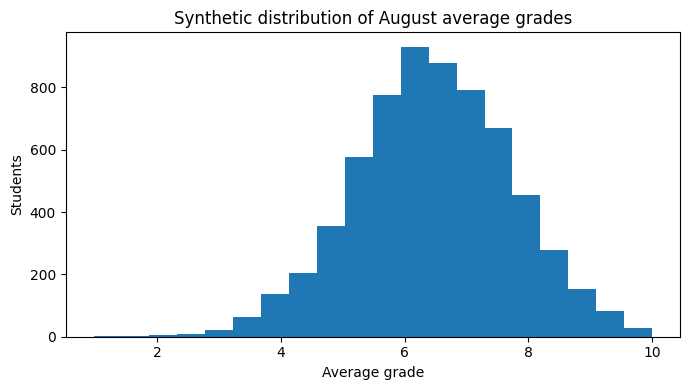

In [15]:
plt.figure(figsize=(7,4))
plt.hist(analytical["avg_august"].dropna(), bins=20)
plt.title("Synthetic distribution of August average grades")
plt.xlabel("Average grade")
plt.ylabel("Students")
plt.tight_layout()
plt.show()

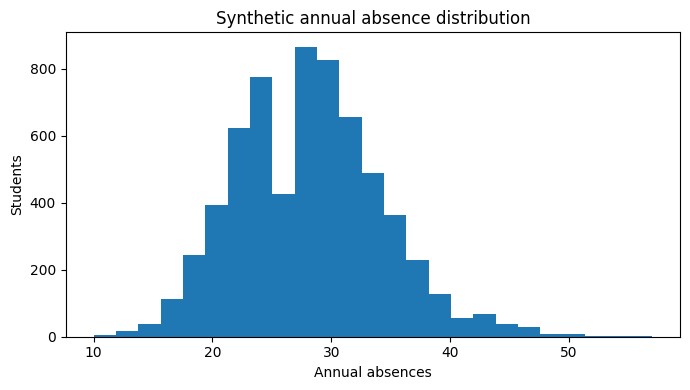

In [16]:
plt.figure(figsize=(7,4))
plt.hist(analytical["annual_absences"].dropna(), bins=25)
plt.title("Synthetic annual absence distribution")
plt.xlabel("Annual absences")
plt.ylabel("Students")
plt.tight_layout()
plt.show()

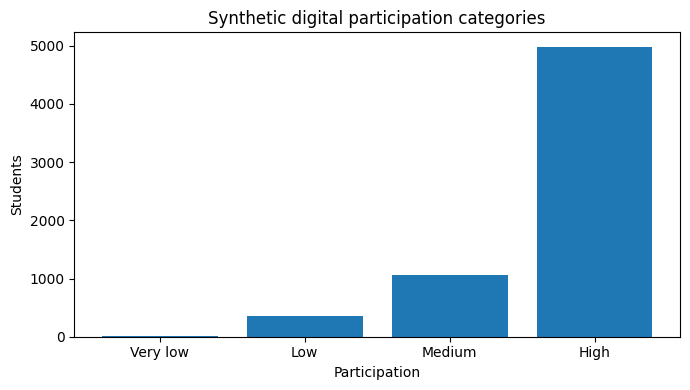

In [17]:
plt.figure(figsize=(7,4))
cats = analytical["digital_participation_category"].value_counts().reindex(["Very low","Low","Medium","High"])
plt.bar(cats.index.astype(str), cats.values)
plt.title("Synthetic digital participation categories")
plt.xlabel("Participation")
plt.ylabel("Students")
plt.tight_layout()
plt.show()

## 10.1 Categorical association test

The original analysis used a chi-square test to evaluate whether two categorical variables were independent.

Interpretation rule:

- `p < 0.05` → evidence of association
- `p >= 0.05` → insufficient evidence of association

In [18]:
contingency = pd.crosstab(
    analytical["digital_participation_category"],
    analytical["zone"]
)
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-square:", round(chi2,3))
print("p-value:", round(p_value,6))
print("Degrees of freedom:", dof)
contingency

Chi-square: 10.009
p-value: 0.018486
Degrees of freedom: 3


zone,Rural,Urban
digital_participation_category,,
Very low,0,5
Low,68,293
Medium,235,830
High,1226,3756


## 10.2 Spearman correlation: digital interaction vs academic performance

Spearman correlation is used because digital activity indicators are skewed/count-based and do not need to satisfy a linear-normal relationship.

In [19]:
corr_rows=[]
for metric in [
    "actions_may","comments_may","logins_may","submissions_may",
    "actions_june","comments_june","logins_june","submissions_june"
]:
    target = "avg_may" if metric.endswith("_may") else "avg_june"
    valid = analytical[[metric,target]].dropna()
    rho,p = spearmanr(valid[metric], valid[target])
    corr_rows.append([metric,target,rho,p])

spearman_table = pd.DataFrame(
    corr_rows, columns=["digital_metric","grade_metric","spearman_rho","p_value"]
)
spearman_table

,digital_metric,grade_metric,spearman_rho,p_value
0,actions_may,avg_may,0.313241,5.388523e-146
1,comments_may,avg_may,0.262355,1.999495e-101
2,logins_may,avg_may,0.302339,1.168878e-135
3,submissions_may,avg_may,0.285283,2.317124e-120
4,actions_june,avg_june,0.312484,2.907185e-145
5,comments_june,avg_june,0.252575,6.702216e-94
6,logins_june,avg_june,0.307418,2.028072e-140
7,submissions_june,avg_june,0.283860,3.923450e-119


## 10.3 Urban/rural and over-age comparisons

In [20]:
zone_summary = analytical.groupby("zone").agg(
    students=("student_id","count"),
    avg_grade=("avg_grade_total","mean"),
    avg_absences=("annual_absences","mean"),
    avg_digital_participation=("digital_participation_score","mean"),
    avg_vulnerability=("vulnerability_index","mean")
)
zone_summary

,students,avg_grade,avg_absences,avg_digital_participation,avg_vulnerability
zone,,,,,
Rural,1529,6.535537,27.894702,41.602354,0.502188
Urban,4884,6.506869,28.263514,40.852170,0.497149


In [21]:
over_age_summary = analytical.groupby("over_age").agg(
    students=("student_id","count"),
    avg_grade=("avg_grade_total","mean"),
    avg_absences=("annual_absences","mean"),
    avg_digital_participation=("digital_participation_score","mean")
)
over_age_summary

,students,avg_grade,avg_absences,avg_digital_participation
over_age,,,,
False,5662,6.591922,27.968032,41.253267
True,751,5.923993,29.740346,39.355526


# 11. Objective 1 — student profiles

The original analytical objective asked:

> What types of 7th-grade student profiles can be identified from academic, digital and contextual variables?

The core dimensions used were:

- grades
- digital participation
- normalized attendance
- sex
- over-age status
- zone
- vulnerability index

For a portfolio version, we summarize interpretable rule-based profiles rather than expose any real subgroup counts.

In [22]:
def profile_student(row):
    if row["avg_june"] < 5.5 and row["avg_absences_per_period"] > 8:
        return "Academic + attendance risk"
    if row["digital_participation_score"] < 18 and row["avg_june"] < 6:
        return "Low digital engagement + academic risk"
    if row["avg_june"] >= 7 and row["digital_participation_score"] >= 30:
        return "High engagement / stable performance"
    return "Mixed / intermediate"

analytical["student_profile"] = analytical.apply(profile_student, axis=1)
analytical["student_profile"].value_counts()

student_profile
Mixed / intermediate                      3282
High engagement / stable performance      2338
Academic + attendance risk                 744
Low digital engagement + academic risk      49
Name: count, dtype: int64

# 12. Target definition: educational trajectory risk

The original final model defined the binary target from the **August academic outcome**:

- `risk = 1` when the August average grade is **≤ 5**
- `risk = 0` when it is **> 5**

To avoid target leakage, the predictive variables use information available **before or independently of the August target**, including May/June performance, grade variability, attendance dynamics, context and digital participation.

In [23]:
analytical["trajectory_risk"] = (analytical["avg_august"].fillna(0) <= 5).astype(int)

target_dist = analytical["trajectory_risk"].value_counts().sort_index()
target_pct = analytical["trajectory_risk"].value_counts(normalize=True).sort_index()

pd.DataFrame({"count":target_dist, "share":target_pct})

,count,share
trajectory_risk,,
0,5645,0.880243
1,768,0.119757


# 13. Modeling dataset and preprocessing

Final predictor families preserved from the original modeling stage:

**Categorical**
- sex
- zone
- vulnerability context
- over-age
- severe chronic absence

**Numeric**
- digital participation score
- May average
- June average
- grade standard deviation
- grade range
- average attendance rate
- attendance volatility

The confidential project used its original vulnerability categories. Here the synthetic numerical index is converted into Low / Medium / High bands for equivalent modeling behavior.

In [24]:
analytical["vulnerability_band"] = pd.cut(
    analytical["vulnerability_index"],
    bins=[-0.01,0.33,0.66,1.01],
    labels=["Low","Medium","High"]
)

cat_features = [
    "sex","zone","vulnerability_band","over_age","chronic_absence_severe"
]
num_features = [
    "digital_participation_score",
    "avg_may","avg_june",
    "grade_std_total","grade_range_total",
    "avg_absences_per_period","absence_volatility"
]

X = analytical[cat_features + num_features].copy()
y = analytical["trajectory_risk"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pre = ColumnTransformer([
    ("cat", cat_pipe, cat_features),
    ("num", num_pipe, num_features)
])

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4489, 12) Test: (1924, 12)


## 13.1 Evaluation helper

The project compared both training and test performance to detect overfitting and tracked recall because missing an at-risk student is especially costly.

In [25]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    row = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, pred_train),
        "test_accuracy": accuracy_score(y_test, pred_test),
        "test_precision_risk": precision_score(y_test, pred_test, zero_division=0),
        "test_recall_risk": recall_score(y_test, pred_test, zero_division=0),
        "test_f1_risk": f1_score(y_test, pred_test, zero_division=0),
        "false_negatives": int(((y_test==1) & (pred_test==0)).sum())
    }
    return row

# 14. Logistic Regression

In [26]:
logistic = Pipeline([
    ("pre", pre),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"))
])
logistic.fit(X_train, y_train)

results = [evaluate_model("Logistic Regression", logistic, X_train, X_test, y_train, y_test)]
pd.DataFrame(results)

,model,train_accuracy,test_accuracy,test_precision_risk,test_recall_risk,test_f1_risk,false_negatives
0,Logistic Regression,0.928937,0.924636,0.621083,0.947826,0.75043,12


# 15. Decision Tree

In [27]:
tree_model = Pipeline([
    ("pre", pre),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])
tree_model.fit(X_train, y_train)

results.append(evaluate_model("Decision Tree", tree_model, X_train, X_test, y_train, y_test))
pd.DataFrame(results)

,model,train_accuracy,test_accuracy,test_precision_risk,test_recall_risk,test_f1_risk,false_negatives
0,Logistic Regression,0.928937,0.924636,0.621083,0.947826,0.750430,12
1,Decision Tree,0.938294,0.926195,0.628655,0.934783,0.751748,15


# 16. Random Forest + GridSearchCV

The original project tuned the Random Forest with cross-validation and optimized for **recall**.

In [28]:
rf_pipe = Pipeline([
    ("pre", pre),
    ("rf", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

param_grid = {
    "rf__n_estimators": [150, 300],
    "rf__max_depth": [10, 20],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2],
    "rf__max_features": ["sqrt"]
}

grid = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_

print("Best parameters:", grid.best_params_)
results.append(evaluate_model("Random Forest", best_rf, X_train, X_test, y_train, y_test))
pd.DataFrame(results)

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 112, in start_daemon
RuntimeError: Failed to start artifact tool daemon (exited early)
Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/sprea

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/client.py", line 134, in call
BrokenPipeError: [Errno 32] Broken pipe

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 715, in _warm_feature_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 167, in _warm_range_and_formatting_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/generated/interface/models.py", line 31668, in 

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.
Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_

Best parameters: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 300}


,model,train_accuracy,test_accuracy,test_precision_risk,test_recall_risk,test_f1_risk,false_negatives
0,Logistic Regression,0.928937,0.924636,0.621083,0.947826,0.750430,12
1,Decision Tree,0.938294,0.926195,0.628655,0.934783,0.751748,15
2,Random Forest,0.977946,0.945426,0.727273,0.869565,0.792079,30


# 17. XGBoost

The original final notebook also evaluated XGBoost with:

- binary logistic objective
- class-imbalance weighting
- shallow trees
- low learning rate
- row/column subsampling
- validation-based early stopping

This public notebook executes XGBoost only when the package is available.

In [29]:
xgb_available = False
try:
    import xgboost as xgb
    xgb_available = True
except Exception as e:
    print("XGBoost is optional in this environment:", e)

if xgb_available:
    # Reuse sklearn preprocessing, then native XGBoost matrices.
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train
    )

    X_tr_p = pre.fit_transform(X_tr)
    X_val_p = pre.transform(X_val)
    X_test_p = pre.transform(X_test)
    X_train_p = pre.transform(X_train)

    neg, pos = y_train.value_counts().sort_index()
    scale_pos_weight = neg / max(pos,1)

    dtrain = xgb.DMatrix(X_tr_p, label=y_tr)
    dval = xgb.DMatrix(X_val_p, label=y_val)
    dtest = xgb.DMatrix(X_test_p, label=y_test)
    dtrain_full = xgb.DMatrix(X_train_p, label=y_train)

    params = {
        "objective":"binary:logistic",
        "eval_metric":"auc",
        "scale_pos_weight":float(scale_pos_weight),
        "max_depth":4,
        "eta":0.05,
        "subsample":0.8,
        "colsample_bytree":0.8,
        "seed":RANDOM_STATE,
        "tree_method":"hist"
    }

    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=500,
        evals=[(dtrain,"train"),(dval,"validation")],
        early_stopping_rounds=30,
        verbose_eval=False
    )

    pred_test = (bst.predict(dtest) >= 0.5).astype(int)
    pred_train = (bst.predict(dtrain_full) >= 0.5).astype(int)

    results.append({
        "model":"XGBoost",
        "train_accuracy":accuracy_score(y_train,pred_train),
        "test_accuracy":accuracy_score(y_test,pred_test),
        "test_precision_risk":precision_score(y_test,pred_test,zero_division=0),
        "test_recall_risk":recall_score(y_test,pred_test,zero_division=0),
        "test_f1_risk":f1_score(y_test,pred_test,zero_division=0),
        "false_negatives":int(((y_test==1)&(pred_test==0)).sum())
    })

pd.DataFrame(results)

,model,train_accuracy,test_accuracy,test_precision_risk,test_recall_risk,test_f1_risk,false_negatives
0,Logistic Regression,0.928937,0.924636,0.621083,0.947826,0.750430,12
1,Decision Tree,0.938294,0.926195,0.628655,0.934783,0.751748,15
2,Random Forest,0.977946,0.945426,0.727273,0.869565,0.792079,30
3,XGBoost,0.944977,0.931913,0.651376,0.926087,0.764811,17


# 18. Final model comparison

This synthetic reconstruction **does not attempt to reproduce the original confidential model scores**.  
The purpose is to reproduce the analytical procedure faithfully.

In the original final notebook, the reported test results were approximately:

- Logistic Regression — 88% accuracy, 88% recall for risk
- Decision Tree — 89% accuracy, 90% recall
- Random Forest — 90% accuracy, 90% recall
- XGBoost — 90% accuracy, 89% recall

The original analysis highlighted Random Forest as particularly stable between train and test, while XGBoost showed a small train/test gap.

Those figures belong to the original project and are documented here only as **project results**, not as results of the synthetic dataset.

In [30]:
comparison = pd.DataFrame(results).copy()
comparison["accuracy_gap"] = comparison["train_accuracy"] - comparison["test_accuracy"]
comparison.sort_values(["test_recall_risk","test_accuracy"], ascending=False)

,model,train_accuracy,test_accuracy,test_precision_risk,test_recall_risk,test_f1_risk,false_negatives,accuracy_gap
0,Logistic Regression,0.928937,0.924636,0.621083,0.947826,0.750430,12,0.004301
1,Decision Tree,0.938294,0.926195,0.628655,0.934783,0.751748,15,0.012098
3,XGBoost,0.944977,0.931913,0.651376,0.926087,0.764811,17,0.013064
2,Random Forest,0.977946,0.945426,0.727273,0.869565,0.792079,30,0.032520


# 19. Data governance, limitations and lessons

### Data governance
- Raw confidential data are excluded from the repository.
- IDs and geographic values in this notebook are synthetic.
- Every transformation that changes the semantic meaning of a metric is documented.
- Row-grain and join cardinality are explicitly validated.
- Model evaluation uses held-out data and train/test comparison.

### Limitations
- Synthetic data cannot preserve the real-world distribution or institutional complexity of the confidential dataset.
- Statistical significance in this public notebook applies only to the synthetic sample.
- Model scores produced here must not be interpreted as evidence about real students.
- The public version intentionally omits exact institution-level cartography.

### What the project demonstrates professionally
This work goes beyond fitting a machine-learning model. It shows an end-to-end analytics workflow:

**raw operational data → quality rules → transformation layer → semantic features → validation → exploratory analysis → statistical tests → predictive modeling → model comparison → documentation/governance**